<a href="https://colab.research.google.com/github/KarlaRL666/DataAnalysisPython/blob/main/ProcesoETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# PROCESO ETL EN RED MUNICIPAL DE AGUA POTABLE
# ============================================
# 1. Importar librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

In [ ]:
# 2. Extract: crear dataset directamente en el código
# Columnas: id_sensor, fecha, presion_bar, caudal_lps
data = {
 "id_sensor": [1,1,1,2,2,2,3,3,3],
 "fecha": ["2026-06-01 08:00","2026-06-01 09:00","2026-06-01 10:00",
 "2026-06-01 08:00","2026-06-01 09:00","2026-06-01 10:00",
 "2026-06-01 08:00","2026-06-01 09:00","2026-06-01 10:00"],
 "presion_bar": [3.5, 2.1, 1.8, 4.0, 3.9, 2.0, 3.8, 3.7, 1.5],
 "caudal_lps": [15, 30, 40, 20, 22, 50, 18, 19, 55]
}
df = pd.DataFrame(data)
print("Datos originales:")
print(df)

Datos originales:
   id_sensor             fecha  presion_bar  caudal_lps
0          1  2026-06-01 08:00          3.5          15
1          1  2026-06-01 09:00          2.1          30
2          1  2026-06-01 10:00          1.8          40
3          2  2026-06-01 08:00          4.0          20
4          2  2026-06-01 09:00          3.9          22
5          2  2026-06-01 10:00          2.0          50
6          3  2026-06-01 08:00          3.8          18
7          3  2026-06-01 09:00          3.7          19
8          3  2026-06-01 10:00          1.5          55


In [ ]:
# 3. Transform: limpieza y enriquecimiento
# Convertir la columna 'fecha' a formato datetime
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
# Crear una nueva columna 'fuga_detectada':
# Si la presión baja (<2 bar) y el caudal sube (>35 lps) → fuga
df["fuga_detectada"] = df.apply(lambda row: "Sí" if row["presion_bar"] < 2 and row["caudal_lps"] > 35
else "No", axis=1)
print("\nDatos transformados:")
print(df)


Datos transformados:
   id_sensor               fecha  presion_bar  caudal_lps fuga_detectada
0          1 2026-06-01 08:00:00          3.5          15             No
1          1 2026-06-01 09:00:00          2.1          30             No
2          1 2026-06-01 10:00:00          1.8          40             Sí
3          2 2026-06-01 08:00:00          4.0          20             No
4          2 2026-06-01 09:00:00          3.9          22             No
5          2 2026-06-01 10:00:00          2.0          50             No
6          3 2026-06-01 08:00:00          3.8          18             No
7          3 2026-06-01 09:00:00          3.7          19             No
8          3 2026-06-01 10:00:00          1.5          55             Sí


In [ ]:
# 4. Load: cargar datos en una base SQLite (local)
conexion = sqlite3.connect("red_agua.db")
df.to_sql("sensores", conexion, if_exists="replace", index=False)
# Verificación: mostrar primeras filas cargadas
print("\nDatos cargados en SQLite:")
print(pd.read_sql("SELECT * FROM sensores LIMIT 5;", conexion))


Datos cargados en SQLite:
   id_sensor                fecha  presion_bar  caudal_lps fuga_detectada
0          1  2026-06-01 08:00:00          3.5          15             No
1          1  2026-06-01 09:00:00          2.1          30             No
2          1  2026-06-01 10:00:00          1.8          40             Sí
3          2  2026-06-01 08:00:00          4.0          20             No
4          2  2026-06-01 09:00:00          3.9          22             No


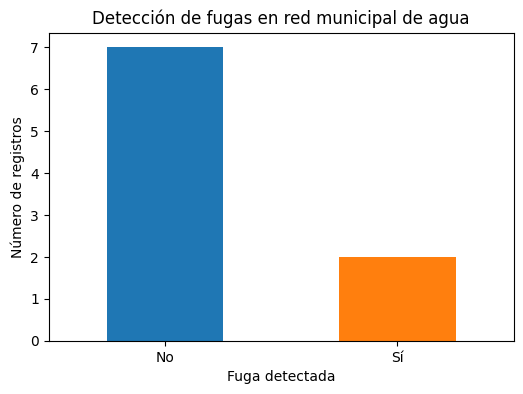

In [ ]:
# 5. Graficación: visualizar fugas detectadas
conteo_fugas = df["fuga_detectada"].value_counts()
plt.figure(figsize=(6,4))
conteo_fugas.plot(kind="bar", color=["#1f77b4", "#ff7f0e"])
plt.title("Detección de fugas en red municipal de agua")
plt.xlabel("Fuga detectada")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)
plt.show()